# Notebook 6 (V02) — Correlation Analysis

**Objective.** Test whether the plant's bioelectric signal co-varies with three
independent raw signals — ambient **CO₂**, participant **HRV**, and
participant **facial expression (FER)** — using a single, consistent
statistical method.


## 1  Configuration

All paths, thresholds and column names used throughout the notebook are
defined here. The reference-signal columns (CO₂, HRV, FER) are *resolved*
against the dataset header in Section 2 — nothing is assumed or invented.


In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from IPython.display import display, Markdown

try:
    from xgboost import XGBClassifier
    XGBOOST_OK = True
except ImportError:
    XGBOOST_OK = False
    print("xgboost not installed - the Top-5 feature ranking will use Random Forest only.")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# --- paths -------------------------------------------------------------
DATASET_CSV = Path("../data/datasets/consolidated_dataset.csv")   # output of Notebook 1
OUTPUT_CSV  = Path("../data/datasets/correlation_analysis_v02_results.csv")

# --- statistics ----------------------------------------------------------
ALPHA          = 0.05        # significance threshold for every test
LAG_RANGE      = range(1, 6)  # test lags of 1-5 windows (windows are 30 s)
ROLLING_WINDOW = 5            # window count for the rolling std variant (~2.5 min)

# --- candidate column names, resolved against the header in Section 2 ---
HRV_COL         = "rmssd"                     # primary HRV marker used throughout the project
                                                # (sole time-domain HRV metric; Notebook 2, "primary time-domain HRV marker")
CO2_CANDIDATES  = ["co2", "co2_ppm", "CO2", "co2_concentration"]
FER_CANDIDATES  = ["fer_valence", "fer_arousal"]   # raw FER model outputs (excludes QC fields
                                                     # fer_confidence / fer_n / fer_quality / face_coverage
                                                     # and the categorical fer_dominant_emotion)

# Candidate plant features (spreadsheet columns Q-AL), mirrored from the
# feature set used by the three ML pipelines (04_01/02/03_ml_pipeline_*).
# Only columns that are actually present *and* vary are used further down.
PLANT_CANDIDATE_FEATURES = [
    "plant_mean", "plant_median", "plant_std", "plant_iqr",
    "plant_min", "plant_max", "plant_range", "plant_rms", "plant_zcr",
    "plant_sat_pos_frac", "plant_sat_neg_frac", "plant_const_flag",
    "bp_0_1", "bp_1_5", "bp_5_15", "bp_15_30", "band_power_sum",
    "plant_dead_flag", "plant_suspect_flag",
]

# Classification targets used by the three ML pipelines - used below only to
# rank plant-feature importance, never as correlation inputs themselves.
ML_PIPELINE_TARGETS = ["label", "arousal_level", "valence_direction"]

print(f"Dataset: {DATASET_CSV.resolve()}")
print(f"Output : {OUTPUT_CSV.resolve()}")


Dataset: /Users/jakobjetter/Documents/Universität zu Köln/2. Semester/COIN Seminar/Project/COIN2026_Team-1_Plant-Emotion-Detector/data/datasets/consolidated_dataset.csv
Output : /Users/jakobjetter/Documents/Universität zu Köln/2. Semester/COIN Seminar/Project/COIN2026_Team-1_Plant-Emotion-Detector/data/datasets/correlation_analysis_v02_results.csv


## 2  Data Loading & Column Resolution

We load the consolidated dataset and resolve the reference-signal columns
against its actual header. Nothing is hard-coded that isn't confirmed to
exist in the data.


In [2]:
df = pd.read_csv(DATASET_CSV)
print(f"Loaded {df.shape[0]} rows x {df.shape[1]} columns "
      f"from {df['session_id'].nunique()} sessions / {df['participant_id'].nunique()} participants")

assert HRV_COL in df.columns, f"expected HRV column '{HRV_COL}' not found in dataset"

CO2_COL = next((c for c in CO2_CANDIDATES if c in df.columns), None)
FER_COLS = [c for c in FER_CANDIDATES if c in df.columns]

resolved = {
    "CO2 column":  CO2_COL if CO2_COL else "NOT FOUND - CO2 analysis will be skipped",
    "HRV column":  HRV_COL,
    "FER column(s)": ", ".join(FER_COLS) if FER_COLS else "NOT FOUND",
}
display(Markdown("**Columns resolved from the dataset header:**\n\n" +
                  "\n".join(f"- **{k}:** `{v}`" for k, v in resolved.items())))


Loaded 284 rows x 50 columns from 15 sessions / 15 participants


**Columns resolved from the dataset header:**

- **CO2 column:** `NOT FOUND - CO2 analysis will be skipped`
- **HRV column:** `rmssd`
- **FER column(s):** `fer_valence, fer_arousal`

CO₂ is streamed live during recording (see Notebook 2) but is kept as
*environmental context only* and is not exported into the windowed,
consolidated dataset used for modelling. Its absence here is expected, not an
error — the CO₂ ↔ Plant analysis below is skipped cleanly for this reason.


## 3  Plant Signal: Top-5 Features (dynamic, from the ML pipelines)

The three ML pipelines (`04_01_ml_pipeline_emotion`, `04_02_ml_pipeline_arousal`,
`04_03_ml_pipeline_valence`) each train a Random Forest and an XGBoost
classifier on the plant features to predict `label`, `arousal_level` and
`valence_direction` respectively, and expose `feature_importances_`.

Rather than hard-coding a Top-5 list, this cell **re-trains the same kind of
models on the current dataset** (same candidate plant-feature set, same three
targets) and ranks features by their mean importance across all
target/model combinations. If the plant feature set or the dataset changes
upstream, re-running this cell automatically updates the Top-5 used for the
rest of the notebook — nothing here is pinned by hand.


In [3]:
candidate_feats = [c for c in PLANT_CANDIDATE_FEATURES if c in df.columns]
nunique = df[candidate_feats].nunique()
candidate_feats = [c for c in candidate_feats if nunique[c] > 1]   # drop constant columns

X = df[candidate_feats].apply(pd.to_numeric, errors="coerce")
X = X.fillna(X.median(numeric_only=True))

importances = []
for target in ML_PIPELINE_TARGETS:
    y = df[target].astype(str)
    rf = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)
    rf.fit(X, y)
    importances.append(pd.Series(rf.feature_importances_, index=candidate_feats, name=f"RF_{target}"))

    if XGBOOST_OK:
        y_enc = LabelEncoder().fit_transform(y)
        xgb = XGBClassifier(n_estimators=300, random_state=RANDOM_STATE,
                             eval_metric="mlogloss", verbosity=0)
        xgb.fit(X, y_enc)
        importances.append(pd.Series(xgb.feature_importances_, index=candidate_feats, name=f"XGB_{target}"))

importance_df = pd.concat(importances, axis=1)
importance_df["mean_importance"] = importance_df.mean(axis=1)
importance_df = importance_df.sort_values("mean_importance", ascending=False)

TOP5_PLANT_FEATURES = importance_df.head(5).index.tolist()

display(importance_df.round(3))
display(Markdown(
    f"**Selected Top-5 plant features (mean importance across "
    f"{importance_df.shape[1]-1} RF/XGBoost models over the three ML-pipeline "
    f"targets):** `{TOP5_PLANT_FEATURES}`\n\n"
    "These five features are used as *the* plant signal throughout the rest "
    "of this notebook."
))


,RF_label,XGB_label,RF_arousal_level,XGB_arousal_level,RF_valence_direction,XGB_valence_direction,mean_importance
plant_max,0.077,0.088,0.083,0.083,0.085,0.096,0.085
plant_range,0.079,0.097,0.074,0.069,0.077,0.086,0.080
plant_mean,0.068,0.078,0.072,0.081,0.070,0.081,0.075
plant_median,0.080,0.091,0.080,0.058,0.071,0.068,0.075
plant_std,0.071,0.069,0.075,0.082,0.074,0.073,0.074
plant_min,0.084,0.070,0.075,0.058,0.084,0.069,0.074
plant_iqr,0.075,0.067,0.075,0.082,0.071,0.071,0.073
bp_5_15,0.067,0.084,0.066,0.071,0.067,0.078,0.072
bp_1_5,0.078,0.076,0.064,0.071,0.062,0.072,0.070
band_power_sum,0.064,0.050,0.066,0.105,0.070,0.064,0.070


**Selected Top-5 plant features (mean importance across 6 RF/XGBoost models over the three ML-pipeline targets):** `['plant_max', 'plant_range', 'plant_mean', 'plant_median', 'plant_std']`

These five features are used as *the* plant signal throughout the rest of this notebook.

## 4  Methodology

**Three analyses**, each against the plant signal (Top-5 features):

1. **CO₂ ↔ Plant** — does ambient CO₂ co-vary with the plant signal?
2. **HRV ↔ Plant** — does participant heart-rate variability co-vary with the plant signal?
3. **FER ↔ Plant** — does facial-expression output co-vary with the plant signal?

**Three variants** per analysis:

1. **Raw** — Spearman correlation of the raw per-window values.
2. **Standard deviation** — Spearman correlation of a rolling, per-session
   standard deviation (window size `ROLLING_WINDOW`) of each signal — tests
   whether the two signals co-vary in their *variability*, not just their level.
3. **Lag** — Spearman correlation between the reference signal and the plant
   signal at lags of 1-5 windows (reference signal shifted forward within
   each session); the strongest absolute ρ and its lag are reported — tests
   whether the plant reacts to the reference signal with a delay.

**Why Spearman, and only Spearman.** Spearman's ρ is rank-based, makes no
assumption of normality, and is robust to outliers — a good uniform choice
across CO₂, HRV and FER signals without needing per-signal method selection.
No Pearson, no Kendall, no normality testing.

**Why only raw, independent signals.** Model outputs (the trained
classifiers' predictions) are *derived from* the plant data and trained on
HRV-based labels — correlating them with the plant signal again would be
circular. Only directly measured signals (CO₂, RMSSD, FER model output) are
used.

**Independence note.** HRV and FER are recorded by entirely separate sensors
(chest strap vs. camera) and are not derived from one another, which makes
**HRV ↔ Plant** and **FER ↔ Plant** the scientifically cleanest of the three
analyses. CO₂ is also independent, but not exported into this dataset (see
Section 2).

Every test reports ρ, p-value and n; ρ is considered significant at
α = `ALPHA`.


## 5  Shared Analysis Helper

One function runs a single Spearman variant (raw / std / lag) between a
reference column and each of the Top-5 plant features. All rolling and lag
operations are computed **per session** (`groupby("session_id")`) so that
windows are never compared across different recordings/participants.


In [4]:
def _rolling_std(series_by_session, window):
    return series_by_session.transform(lambda s: s.rolling(window, min_periods=window).std())


def _shift(series_by_session, lag):
    return series_by_session.transform(lambda s: s.shift(lag))


def analyze_pair(data, ref_col, plant_features, variant, window=ROLLING_WINDOW, lags=LAG_RANGE):
    # Run one Spearman variant (raw/std/lag) between ref_col and each plant feature.
    # Returns a results DataFrame (one row per plant feature) and, for the lag
    # variant, a dict of per-feature {lag: rho} curves for plotting.
    rows, lag_curves = [], {}

    for feat in plant_features:
        if variant == "raw":
            sub = data[[ref_col, feat]].dropna()
            rho, p, n = (*spearmanr(sub[ref_col], sub[feat]), len(sub)) if len(sub) >= 3 else (np.nan, np.nan, len(sub))
            rows.append(dict(plant_feature=feat, rho=rho, p_value=p, n=n, best_lag=np.nan))

        elif variant == "std":
            x_std = _rolling_std(data.groupby("session_id")[ref_col], window)
            y_std = _rolling_std(data.groupby("session_id")[feat], window)
            sub = pd.DataFrame({"x": x_std, "y": y_std}).dropna()
            rho, p, n = (*spearmanr(sub["x"], sub["y"]), len(sub)) if len(sub) >= 3 else (np.nan, np.nan, len(sub))
            rows.append(dict(plant_feature=feat, rho=rho, p_value=p, n=n, best_lag=np.nan))

        elif variant == "lag":
            curve = []
            for lag in lags:
                shifted_ref = _shift(data.groupby("session_id")[ref_col], lag)
                sub = pd.DataFrame({"x": shifted_ref, "y": data[feat]}).dropna()
                if len(sub) >= 3:
                    rho, p = spearmanr(sub["x"], sub["y"])
                    curve.append(dict(lag=lag, rho=rho, p_value=p, n=len(sub)))
            curve_df = pd.DataFrame(curve)
            lag_curves[feat] = curve_df
            if len(curve_df):
                best = curve_df.loc[curve_df["rho"].abs().idxmax()]
                rows.append(dict(plant_feature=feat, rho=best["rho"], p_value=best["p_value"],
                                  n=int(best["n"]), best_lag=int(best["lag"])))
            else:
                rows.append(dict(plant_feature=feat, rho=np.nan, p_value=np.nan, n=0, best_lag=np.nan))
        else:
            raise ValueError(f"unknown variant: {variant}")

    return pd.DataFrame(rows), lag_curves


def plot_raw(data, ref_col, ref_label, plant_features, res_raw):
    fig, axes = plt.subplots(1, len(plant_features), figsize=(3.4 * len(plant_features), 3.2))
    for ax, feat in zip(axes, plant_features):
        sub = data[[ref_col, feat]].dropna()
        sns.regplot(x=ref_col, y=feat, data=sub, ax=ax,
                     scatter_kws=dict(s=12, alpha=0.5), line_kws=dict(color="crimson"))
        rho = res_raw.loc[res_raw.plant_feature == feat, "rho"].values[0]
        ax.set_title(f"{feat}\nρ={rho:.2f}", fontsize=10)
        ax.set_xlabel(ref_label, fontsize=9)
    fig.suptitle(f"{ref_label} vs. Plant Top-5 (raw)")
    plt.tight_layout()
    plt.show()


def plot_lag(lag_curves, ref_label):
    fig, ax = plt.subplots(figsize=(6, 4))
    for feat, curve in lag_curves.items():
        if len(curve):
            ax.plot(curve["lag"], curve["rho"], marker="o", label=feat)
    ax.axhline(0, color="grey", lw=0.8)
    ax.set_xlabel("Lag (windows, 30 s each)")
    ax.set_ylabel("Spearman ρ")
    ax.set_title(f"{ref_label} -> Plant: ρ across lags 1-5")
    ax.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()


def run_section(data, ref_col, ref_label, plant_features, window=ROLLING_WINDOW, lags=LAG_RANGE, alpha=ALPHA):
    # Run all three variants for one reference signal, print + plot, return tidy results.
    print(f"\n=== {ref_label} <-> Plant (Top-5) ===")
    all_rows = []
    for variant in ["raw", "std", "lag"]:
        res, lag_curves = analyze_pair(data, ref_col, plant_features, variant, window, lags)
        res.insert(0, "variant", variant)
        res.insert(0, "analysis", ref_label)
        res["significant"] = res["p_value"] < alpha
        all_rows.append(res)

        mean_abs_rho = res["rho"].abs().mean()
        print(f"\n[{variant}] mean |ρ| across 5 features = {mean_abs_rho:.3f}")
        print(res.drop(columns=["analysis", "variant"]).to_string(index=False))

        if variant == "raw":
            plot_raw(data, ref_col, ref_label, plant_features, res)
        elif variant == "lag":
            plot_lag(lag_curves, ref_label)

    return pd.concat(all_rows, ignore_index=True)


## 6  Analysis 1 — CO₂ ↔ Plant

Ambient CO₂ is recorded during sessions but, as noted in Section 2, is not
part of the exported window features in this dataset version. The analysis
runs automatically if a CO₂ column is ever added upstream; otherwise it is
skipped here with a clear message rather than failing.


In [5]:
if CO2_COL is None:
    print("CO2 column not found in the consolidated dataset - skipping CO2 <-> Plant analysis.")
    results_co2 = pd.DataFrame(columns=["analysis", "variant", "plant_feature", "rho", "p_value", "n", "best_lag", "significant"])
else:
    results_co2 = run_section(df, CO2_COL, "CO2", TOP5_PLANT_FEATURES)


CO2 column not found in the consolidated dataset - skipping CO2 <-> Plant analysis.


## 7  Analysis 2 — HRV ↔ Plant

RMSSD is the project's primary time-domain HRV marker (Notebook 2) and the
sole determinant of the HRV-based arousal signal. It is used here in its
**raw** form — not the derived `arousal_hrv` z-score, which mixes in heart
rate and session-level calibration and is no longer a directly measured
signal.



=== HRV (RMSSD) <-> Plant (Top-5) ===

[raw] mean |ρ| across 5 features = 0.080
plant_feature       rho  p_value   n  best_lag  significant
    plant_max -0.063788 0.284020 284       NaN        False
  plant_range -0.051684 0.385542 284       NaN        False
   plant_mean -0.116735 0.049380 284       NaN         True
 plant_median -0.079499 0.181565 284       NaN        False
    plant_std  0.090737 0.127128 284       NaN        False


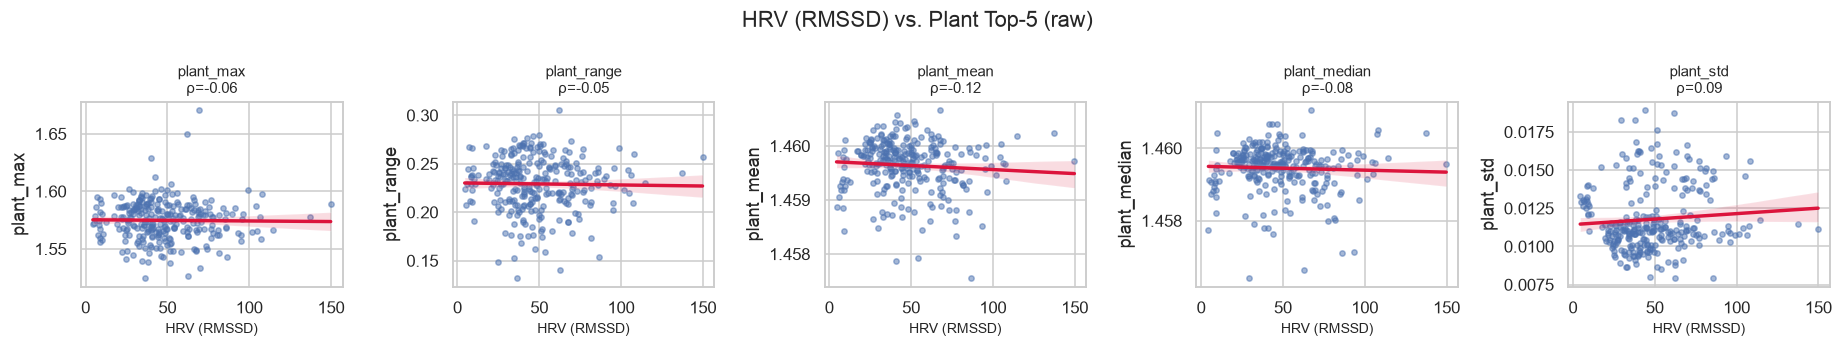


[std] mean |ρ| across 5 features = 0.030
plant_feature       rho  p_value   n  best_lag  significant
    plant_max  0.097850 0.144347 224       NaN        False
  plant_range  0.006635 0.921342 224       NaN        False
   plant_mean  0.001036 0.987702 224       NaN        False
 plant_median -0.019578 0.770744 224       NaN        False
    plant_std  0.025042 0.709334 224       NaN        False

[lag] mean |ρ| across 5 features = 0.115
plant_feature       rho  p_value   n  best_lag  significant
    plant_max -0.070524 0.310246 209         5        False
  plant_range -0.060557 0.322421 269         1        False
   plant_mean -0.180518 0.005124 239         3         True
 plant_median -0.157051 0.018673 224         4         True
    plant_std  0.107995 0.077031 269         1        False


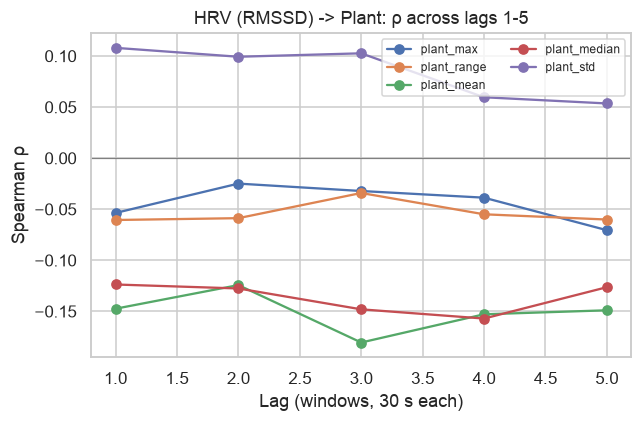

In [6]:
results_hrv = run_section(df, HRV_COL, "HRV (RMSSD)", TOP5_PLANT_FEATURES)


## 8  Analysis 3 — FER ↔ Plant

The dataset carries two raw FER model outputs, used as-is: `fer_valence` and
`fer_arousal`. Both are run against the plant Top-5 with the same shared
helper, so the two are directly comparable to each other and to the CO₂/HRV
sections above.



=== FER (fer_valence) <-> Plant (Top-5) ===

[raw] mean |ρ| across 5 features = 0.174
plant_feature       rho  p_value   n  best_lag  significant
    plant_max -0.186318 0.001612 284       NaN         True
  plant_range -0.189611 0.001325 284       NaN         True
   plant_mean  0.152495 0.010064 284       NaN         True
 plant_median  0.105304 0.076440 284       NaN        False
    plant_std -0.236680 0.000056 284       NaN         True


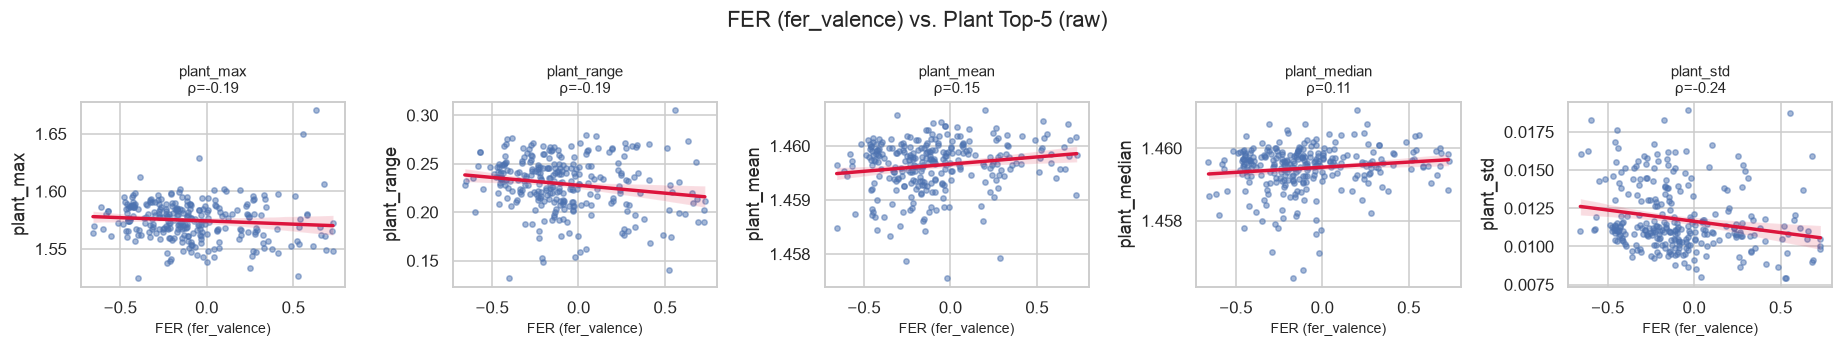


[std] mean |ρ| across 5 features = 0.140
plant_feature       rho  p_value   n  best_lag  significant
    plant_max -0.098268 0.142630 224       NaN        False
  plant_range  0.090759 0.175879 224       NaN        False
   plant_mean  0.128659 0.054503 224       NaN        False
 plant_median  0.107514 0.108542 224       NaN        False
    plant_std  0.273031 0.000034 224       NaN         True

[lag] mean |ρ| across 5 features = 0.189
plant_feature       rho  p_value   n  best_lag  significant
    plant_max -0.220409 0.001342 209         5         True
  plant_range -0.255517 0.000188 209         5         True
   plant_mean  0.126230 0.038548 269         1         True
 plant_median  0.091211 0.135669 269         1        False
    plant_std -0.252076 0.000081 239         3         True


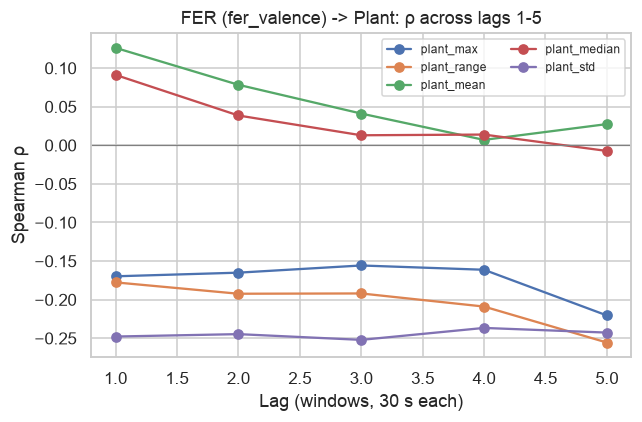


=== FER (fer_arousal) <-> Plant (Top-5) ===

[raw] mean |ρ| across 5 features = 0.087
plant_feature       rho  p_value   n  best_lag  significant
    plant_max  0.071664 0.228619 284       NaN        False
  plant_range  0.112001 0.059418 284       NaN        False
   plant_mean -0.006306 0.915739 284       NaN        False
 plant_median  0.067511 0.256798 284       NaN        False
    plant_std -0.177899 0.002623 284       NaN         True


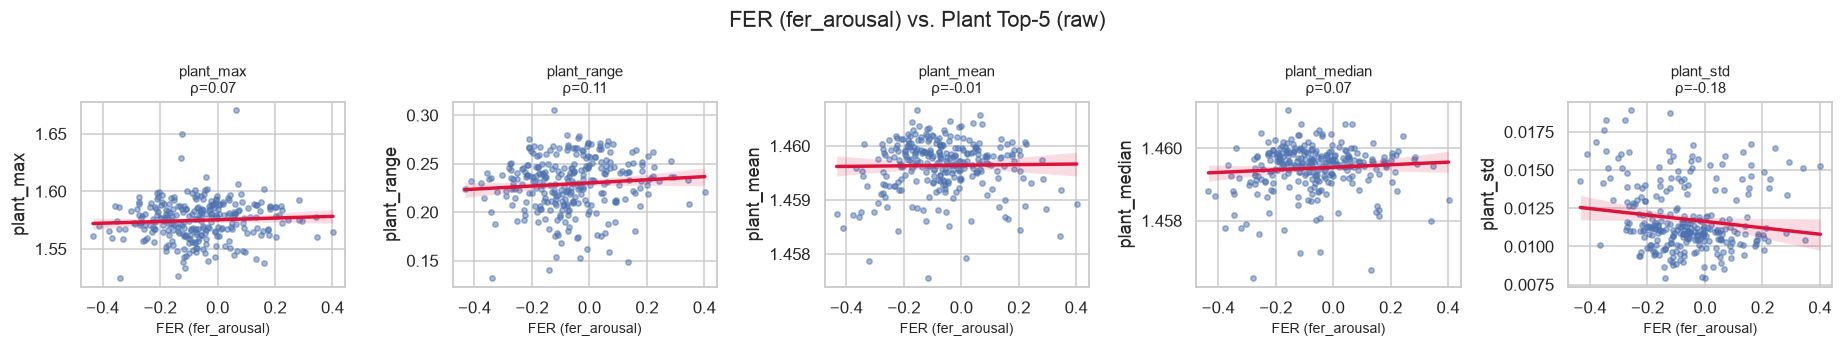


[std] mean |ρ| across 5 features = 0.082
plant_feature       rho  p_value   n  best_lag  significant
    plant_max -0.111625 0.095611 224       NaN        False
  plant_range  0.016432 0.806790 224       NaN        False
   plant_mean  0.097586 0.145437 224       NaN        False
 plant_median  0.011544 0.863579 224       NaN        False
    plant_std  0.170944 0.010376 224       NaN         True

[lag] mean |ρ| across 5 features = 0.104
plant_feature       rho  p_value   n  best_lag  significant
    plant_max  0.061727 0.313147 269         1        False
  plant_range  0.088753 0.146571 269         1        False
   plant_mean  0.049582 0.460282 224         4        False
 plant_median  0.129673 0.045214 239         3         True
    plant_std -0.191994 0.002879 239         3         True


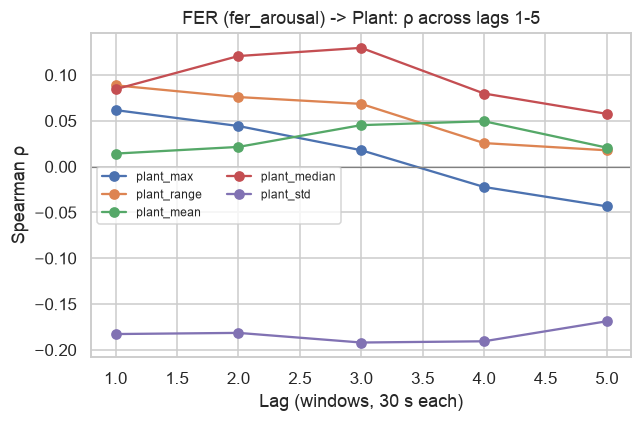

In [7]:
results_fer = pd.concat(
    [run_section(df, col, f"FER ({col})", TOP5_PLANT_FEATURES) for col in FER_COLS],
    ignore_index=True,
) if FER_COLS else pd.DataFrame(columns=["analysis", "variant", "plant_feature", "rho", "p_value", "n", "best_lag", "significant"])


## 9  Final Summary

All analyses and variants are combined into one tidy table (one row per
plant feature, plus a `MEAN` aggregate row per analysis/variant for a
quick at-a-glance comparison), one comparison figure, and a CSV export.


In [8]:
all_results = pd.concat([results_co2, results_hrv, results_fer], ignore_index=True)

agg_rows = []
for (analysis, variant), grp in all_results.groupby(["analysis", "variant"]):
    agg_rows.append(dict(
        analysis=analysis, variant=variant, plant_feature="MEAN",
        rho=grp["rho"].abs().mean(), p_value=np.nan, n=int(grp["n"].median()),
        best_lag=grp["best_lag"].mode().iloc[0] if grp["best_lag"].notna().any() else np.nan,
        significant=grp["significant"].mean() >= 0.5,
    ))

summary = pd.concat([all_results, pd.DataFrame(agg_rows)], ignore_index=True)
summary = summary.sort_values(["analysis", "variant", "plant_feature"]).reset_index(drop=True)

pd.set_option("display.max_rows", 200)
display(summary)

summary.to_csv(OUTPUT_CSV, index=False)
print(f"\nSaved {len(summary)} rows to {OUTPUT_CSV.resolve()}")


,analysis,variant,plant_feature,rho,p_value,n,best_lag,significant
0,FER (fer_arousal),lag,MEAN,0.104346,NaN,239,1.0,False
1,FER (fer_arousal),lag,plant_max,0.061727,0.313147,269,1.0,False
2,FER (fer_arousal),lag,plant_mean,0.049582,0.460282,224,4.0,False
3,FER (fer_arousal),lag,plant_median,0.129673,0.045214,239,3.0,True
4,FER (fer_arousal),lag,plant_range,0.088753,0.146571,269,1.0,False
5,FER (fer_arousal),lag,plant_std,-0.191994,0.002879,239,3.0,True
6,FER (fer_arousal),raw,MEAN,0.087076,NaN,284,NaN,False
7,FER (fer_arousal),raw,plant_max,0.071664,0.228619,284,NaN,False
8,FER (fer_arousal),raw,plant_mean,-0.006306,0.915739,284,NaN,False
9,FER (fer_arousal),raw,plant_median,0.067511,0.256798,284,NaN,False



Saved 54 rows to /Users/jakobjetter/Documents/Universität zu Köln/2. Semester/COIN Seminar/Project/COIN2026_Team-1_Plant-Emotion-Detector/data/datasets/correlation_analysis_v02_results.csv


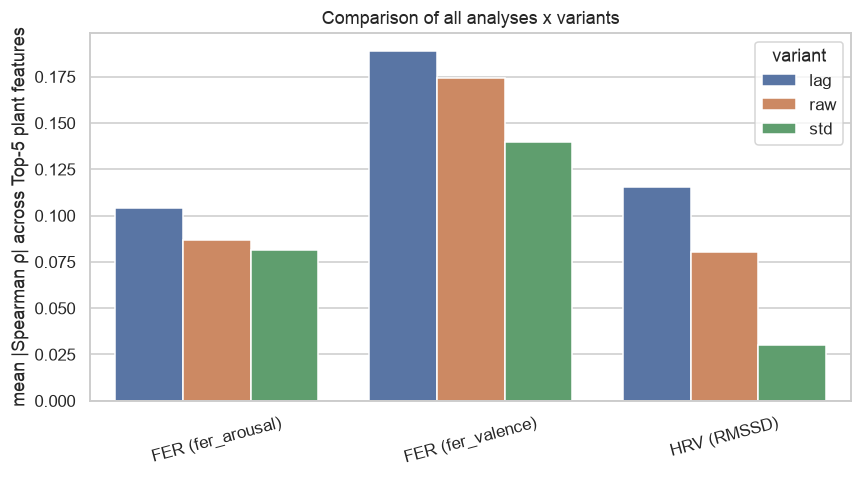

In [9]:
agg = summary[summary["plant_feature"] == "MEAN"].copy()
agg["label"] = agg["analysis"]

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(data=agg, x="label", y="rho", hue="variant", ax=ax)
ax.axhline(0, color="grey", lw=0.8)
ax.set_ylabel("mean |Spearman ρ| across Top-5 plant features")
ax.set_xlabel("")
ax.set_title("Comparison of all analyses x variants")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


## 10  Discussion

None of the three analyses correlate the plant signal with a *model output*
— every ρ above reflects a direct relationship between two independently
measured (or environmental) signals and the plant's own bioelectric
features, so any significant result here is not an artefact of how the
labels were constructed.

**HRV ↔ Plant** and **FER ↔ Plant** are the cleanest tests, since HRV
(chest-strap ECG) and FER (camera-based facial expression) are captured by
independent sensors and are not derived from one another. **CO₂ ↔ Plant**
is currently skipped because CO₂ is not exported into the consolidated
dataset (Section 2) — adding that export would make the analysis run
automatically without any notebook changes.

Read the table and figure in Section 9 together with the per-analysis
output above: a low mean |ρ| in the *raw* variant does not rule out a
relationship — check the *std* variant (co-variability) and the *lag*
variant (delayed response) before concluding a signal pair is unrelated.
